## Angular Spectrum Propagation

This notebook covers Angular Spectrum Propagation to understand the **forward model** behind lensless imaging:

$$
U(x,y,0) \rightarrow U(x,y,z) \rightarrow I(x,y,z)=|U(x,y,z)|^2.
$$

This is the same conceptual chain used later in holography, CDI, phase retrieval, ptychography, and computational 3D lensless imaging.

### Big picture

The angular spectrum method says: any field in a plane can be decomposed into plane waves. Each plane wave has transverse wave-vector components $k_x,k_y$, and therefore a longitudinal component

$$
k_z = \sqrt{k^2-k_x^2-k_y^2}, \qquad k=\frac{2\pi}{\lambda}.
$$

After a propagation distance $z$, that plane wave accumulates phase

$$
\exp(i k_z z).
$$

Therefore:

$$
U(x,y,z)=\mathcal{F}^{-1}\left\{\mathcal{F}\{U(x,y,0)\}\,H(f_x,f_y;z)\right\},
$$

with

$$
H(f_x,f_y;z)=\exp\left(i z\sqrt{k^2-(2\pi f_x)^2-(2\pi f_y)^2}\right).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fourier functions

In [2]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Physical parameters 

In [3]:
N = 512
L = 100e-6
radius = 30e-6
wavelength = 500e-9
z = 50e-6

dx = L / N
k = 2 * np.pi / wavelength

print(f"N = {N}")
print(f"Field of view L = {L*1e6:.1f} µm")
print(f"Pixel pitch dx = {dx*1e9:.2f} nm")
print(f"Wavelength λ = {wavelength*1e9:.1f} nm")
print(f"Propagation distance z = {z*1e6:.1f} µm")
print(f"Wavenumber k = {k:.3e} rad/m")

N = 512
Field of view L = 100.0 µm
Pixel pitch dx = 195.31 nm
Wavelength λ = 500.0 nm
Propagation distance z = 50.0 µm
Wavenumber k = 1.257e+07 rad/m


### Frequency axis construction

In [4]:
x = (np.arange(N) - N/2) * dx
fx = (np.arange(N) - N/2) / L

X, Y = np.meshgrid(x, x, indexing="xy")
FX, FY = np.meshgrid(fx, fx, indexing="xy")
KX = 2 * np.pi * FX
KY = 2 * np.pi * FY

### Input field: circular aperture

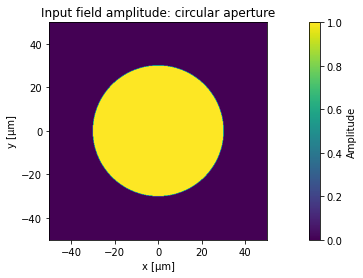

In [5]:
R = np.sqrt(X**2 + Y**2)
aperture = (R < radius).astype(float)

plt.figure()
plt.imshow(aperture, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower")
plt.xlabel("x [µm]")
plt.ylabel("y [µm]")
plt.title("Input field amplitude: circular aperture")
plt.colorbar(label="Amplitude")
plt.axis("image")
plt.show()

### Angular spectrum of the aperture

The Fourier transform of the aperture is its **angular spectrum**. It tells us how much of each plane-wave direction is present in the field.

Low spatial frequencies correspond to nearly axial plane waves. High spatial frequencies correspond to strongly tilted plane waves. If the transverse wave-vector magnitude is too large,

$$
k_x^2+k_y^2>k^2,
$$

then $k_z$ becomes imaginary. Those are **evanescent** components. They decay exponentially with propagation distance and do not carry energy to the far field.

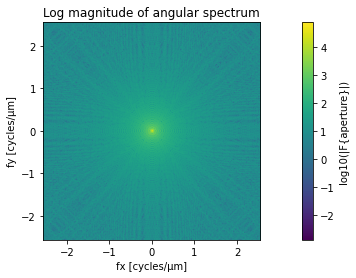

In [6]:
A_spectrum = F2d(aperture)
log_spectrum = np.log10(np.abs(A_spectrum) + 1e-3)

plt.figure()
plt.imshow(log_spectrum, extent=[fx[0]/1e6, fx[-1]/1e6, fx[0]/1e6, fx[-1]/1e6], origin="lower")
plt.xlabel("fx [cycles/µm]")
plt.ylabel("fy [cycles/µm]")
plt.title("Log magnitude of angular spectrum")
plt.colorbar(label="log10(|F{aperture}|)")
plt.axis("image")
plt.show()

### Propagation transfer function

Fraction of Fourier grid corresponding to propagating waves: 0.479
Fraction corresponding to evanescent waves: 0.521


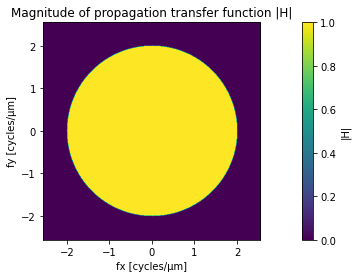

In [7]:
kz = np.sqrt((k**2 - KX**2 - KY**2).astype(complex))
H = np.exp(1j * kz * z)

propagating_mask = (KX**2 + KY**2) <= k**2
fraction_propagating = np.mean(propagating_mask)

print(f"Fraction of Fourier grid corresponding to propagating waves: {fraction_propagating:.3f}")
print(f"Fraction corresponding to evanescent waves: {1 - fraction_propagating:.3f}")

plt.figure()
plt.imshow(np.abs(H), extent=[fx[0]/1e6, fx[-1]/1e6, fx[0]/1e6, fx[-1]/1e6], origin="lower")
plt.xlabel("fx [cycles/µm]")
plt.ylabel("fy [cycles/µm]")
plt.title("Magnitude of propagation transfer function |H|")
plt.colorbar(label="|H|")
plt.axis("image")
plt.show()

### Propagate the field

1. Fourier-transform the aperture field.
2. Multiply each plane-wave component by its propagation factor.
3. Inverse Fourier-transform back to real space.

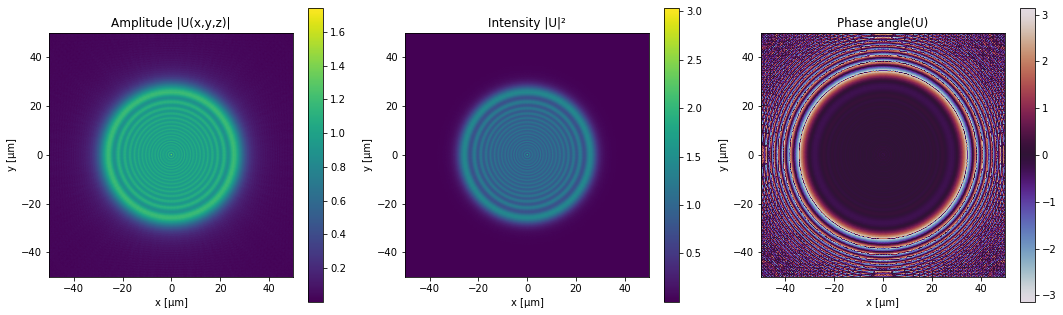

In [8]:
propfield = iF2d(F2d(aperture) * H)

amplitude = np.abs(propfield)
intensity = amplitude**2
phase = np.angle(propfield)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(amplitude, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower")
axes[0].set_title("Amplitude |U(x,y,z)|")
axes[0].set_xlabel("x [µm]")
axes[0].set_ylabel("y [µm]")
axes[0].axis("image")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(intensity, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower")
axes[1].set_title("Intensity |U|²")
axes[1].set_xlabel("x [µm]")
axes[1].set_ylabel("y [µm]")
axes[1].axis("image")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(phase, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower", cmap="twilight")
axes[2].set_title("Phase angle(U)")
axes[2].set_xlabel("x [µm]")
axes[2].set_ylabel("y [µm]")
axes[2].axis("image")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

### Result observasions

The input aperture was purely real and binary: amplitude 1 inside the aperture and 0 outside.

After propagation, the field is no longer just a binary aperture. It has:

- a nontrivial amplitude distribution,
- a nontrivial phase distribution,
- diffraction ripples near the aperture edge,
- intensity redistribution caused by interference between plane-wave components.

The detector would measure only:

$$
I(x,y,z)=|U(x,y,z)|^2.
$$

But the field also has phase:

$$
\phi(x,y,z)=\arg(U(x,y,z)).
$$

That phase is invisible to a camera. This is exactly the phase-loss problem behind phase retrieval and lensless imaging.

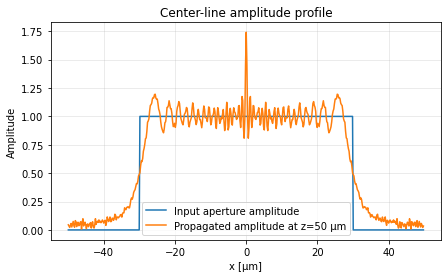

In [9]:
# A horizontal line profile through the center helps us see the diffraction ripples.
center = N // 2

plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, aperture[center, :], label="Input aperture amplitude")
plt.plot(x * 1e6, amplitude[center, :], label=f"Propagated amplitude at z={z*1e6:.0f} µm")
plt.xlabel("x [µm]")
plt.ylabel("Amplitude")
plt.title("Center-line amplitude profile")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Angular spectrum function

Not to rewrite the angular spectrum code every time.

So we define a function:

```python
angular_spectrum_propagate(U0, dx, wavelength, z)
```

Inputs:

- `U0`: complex field at the input plane,
- `dx`: pixel pitch,
- `wavelength`: wavelength,
- `z`: propagation distance.

Output:

- propagated complex field at distance `z`.

In [14]:
def angular_spectrum_propagate(U0, dx, wavelength, z):
    # Number of pixels. We assume a square grid for now.
    N = U0.shape[0]
    assert U0.shape[0] == U0.shape[1]

    # Physical field of view from pixel pitch.
    L = N * dx

    # Frequency coordinates in cycles/meter.
    fx = (np.arange(N) - N/2) / L
    FX, FY = np.meshgrid(fx, fx, indexing="xy")

    # Convert to wave-vector components.
    KX = 2 * np.pi * FX
    KY = 2 * np.pi * FY
    k = 2 * np.pi / wavelength

    # Complex square root is important for evanescent components.
    kz = np.sqrt((k**2 - KX**2 - KY**2).astype(complex))
    H = np.exp(1j * kz * z)

    return iF2d(F2d(U0) * H)


### Propagation as a function of distance

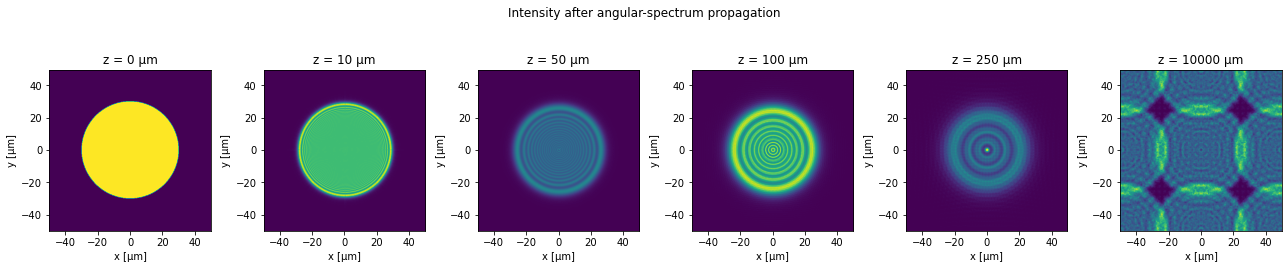

In [15]:
z_values = [0, 10e-6, 50e-6, 100e-6, 250e-6, 1e-2]

fig, axes = plt.subplots(1, len(z_values), figsize=(18, 3.8))
for ax, zi in zip(axes, z_values):
    Uz = angular_spectrum_propagate(aperture, dx, wavelength, zi)
    im = ax.imshow(np.abs(Uz)**2, extent=[x[0]*1e6, x[-1]*1e6, x[0]*1e6, x[-1]*1e6], origin="lower")
    ax.set_title(f"z = {zi*1e6:.0f} µm")
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    ax.axis("image")
plt.suptitle("Intensity after angular-spectrum propagation")
plt.tight_layout()
plt.show()

### Result observations

At very small $z$, the field still resembles the aperture. As $z$ increases, the sharp edge causes diffraction. At sufficiently large $z$, the intensity approaches a far-field diffraction pattern.

Note for very large distance z: numerical artifact is observed. 

Why this happens: As propagation distance $z$ increases, the phase gradient of the transfer function of Angular Spectrum Method becomes steeper, meaning the Fourier transform requires a broader frequency range to resolve the rapid phase changes. Once this gradient becomes too steep for our spatial resolution $dx$ to sample, the frequency window (bounded by $1/dx$ under-samples the phase. This triggers aliasing, causing multiple displaced copies of the field to wrap around, overlap, and create numerical artifacts in the computational window.